# DRD2 Hi — Model complexity plots

This notebook visualizes how model complexity changes when hyperparameters are selected with:

- OOD holdout
- random shuffle

The goal is to connect:

- selected hyperparameters
- model complexity
- train-validation-test gaps
- final OOD generalization

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("../..").resolve()

DATA_DIR = (
    PROJECT_ROOT
    / "results"
    / "results_ood_vs_random_shuffle"
    / "hi"
    / "drd2"
)

FIG_DIR = DATA_DIR / "figures_complexity"
FIG_DIR.mkdir(parents=True, exist_ok=True)

complexity_all = pd.read_csv(DATA_DIR / "complexity_all.csv")
lr_table = pd.read_csv(DATA_DIR / "complexity_lr.csv")
svm_table = pd.read_csv(DATA_DIR / "complexity_svm.csv")
dt_table = pd.read_csv(DATA_DIR / "complexity_dt.csv")
gap_analysis = pd.read_csv(DATA_DIR / "complexity_gap_analysis.csv")
complexity_summary = pd.read_csv(DATA_DIR / "complexity_summary.csv")

complexity_all.head()

,model,model_short,fingerprint,protocol,result_dir,fold,inner_pr_auc,inner_train_pr_auc,train_pr_auc,test_pr_auc,...,l1_norm,l2_norm,approx_margin,intercept,C,penalty,l1_ratio,dual,n_support_per_class,n_support_total
0,Decision Tree,DT,ECFP4,OOD holdout,dt_drd2_hi_inner_ood_holdout_ecfp4,1,0.855177,0.917171,0.9080,0.6979,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Decision Tree,DT,ECFP4,OOD holdout,dt_drd2_hi_inner_ood_holdout_ecfp4,2,0.699841,0.873181,0.8189,0.7698,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Decision Tree,DT,ECFP4,OOD holdout,dt_drd2_hi_inner_ood_holdout_ecfp4,3,0.737516,0.905641,0.8232,0.6815,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Decision Tree,DT,ECFP4,Random shuffle,dt_drd2_hi_random_shuffle_ecfp4,1,0.911535,0.960189,0.9522,0.6237,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Decision Tree,DT,ECFP4,Random shuffle,dt_drd2_hi_random_shuffle_ecfp4,2,0.844398,0.904329,0.8757,0.7540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Decision Tree complexity: number of nodes

A larger tree usually indicates higher model complexity.

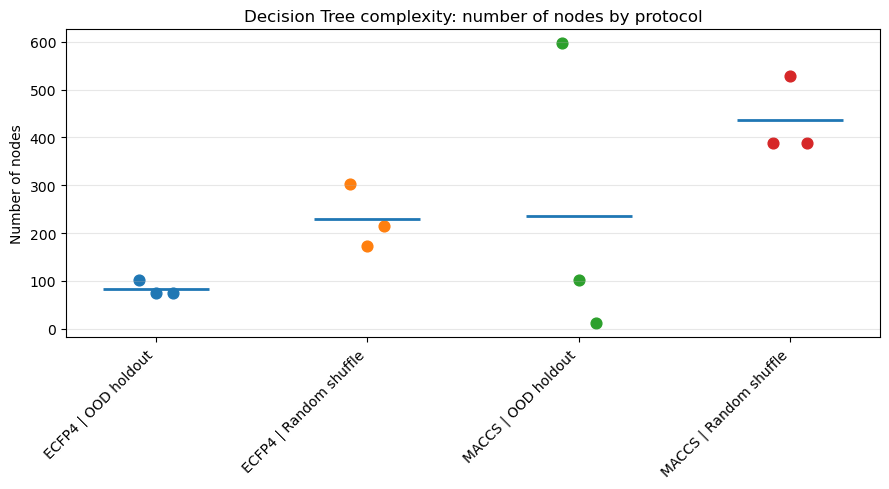

In [3]:
plot_df = dt_table.copy()
plot_df["experiment_label"] = plot_df["fingerprint"] + " | " + plot_df["protocol"]

labels = plot_df["experiment_label"].unique()
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(9, 5))

for i, label in enumerate(labels):
    values = plot_df.loc[plot_df["experiment_label"] == label, "n_nodes"].values
    jitter = np.linspace(-0.08, 0.08, len(values))
    ax.scatter(np.repeat(i, len(values)) + jitter, values, s=60)

    ax.hlines(
        np.mean(values),
        i - 0.25,
        i + 0.25,
        linewidth=2,
    )

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Number of nodes")
ax.set_title("Decision Tree complexity: number of nodes by protocol")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_dt_n_nodes_by_protocol.png", dpi=300, bbox_inches="tight")
plt.show()

# DT effective depth

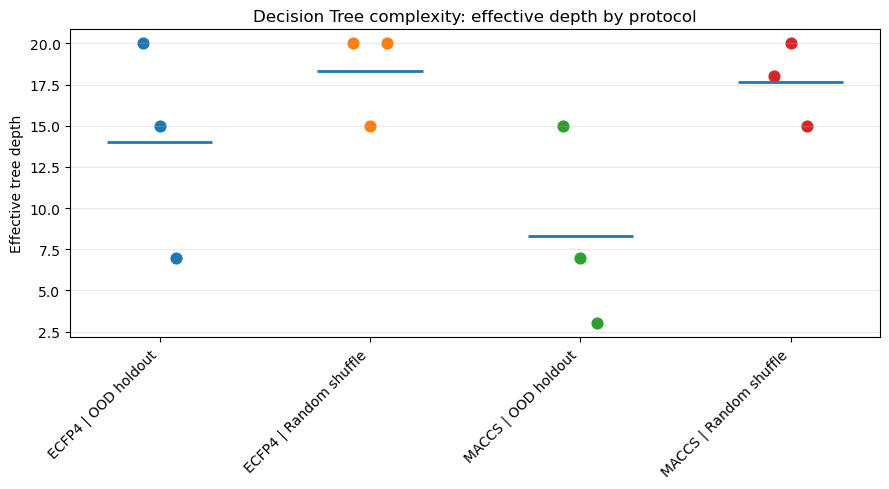

In [4]:
plot_df = dt_table.copy()
plot_df["experiment_label"] = plot_df["fingerprint"] + " | " + plot_df["protocol"]

labels = plot_df["experiment_label"].unique()
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(9, 5))

for i, label in enumerate(labels):
    values = plot_df.loc[plot_df["experiment_label"] == label, "effective_depth"].values
    jitter = np.linspace(-0.08, 0.08, len(values))
    ax.scatter(np.repeat(i, len(values)) + jitter, values, s=60)
    ax.hlines(np.mean(values), i - 0.25, i + 0.25, linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Effective tree depth")
ax.set_title("Decision Tree complexity: effective depth by protocol")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_dt_effective_depth_by_protocol.png", dpi=300, bbox_inches="tight")
plt.show()

# DT n_nodes vs gap

If I increase gap, I also inccrease gap?

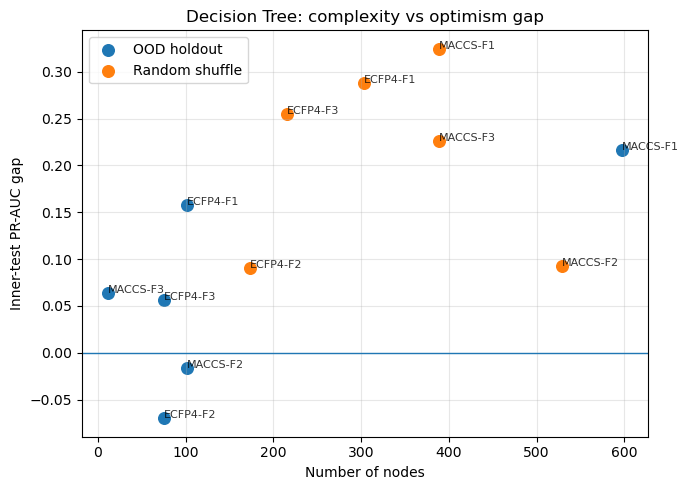

In [5]:
plot_df = dt_table.copy()

fig, ax = plt.subplots(figsize=(7, 5))

for protocol in plot_df["protocol"].unique():
    sub = plot_df[plot_df["protocol"] == protocol]

    ax.scatter(
        sub["n_nodes"],
        sub["inner_test_gap"],
        s=70,
        label=protocol,
    )

for _, row in plot_df.iterrows():
    ax.text(
        row["n_nodes"],
        row["inner_test_gap"],
        f"{row['fingerprint']}-F{int(row['fold'])}",
        fontsize=8,
        alpha=0.8,
    )

ax.axhline(0, linewidth=1)
ax.set_xlabel("Number of nodes")
ax.set_ylabel("Inner-test PR-AUC gap")
ax.set_title("Decision Tree: complexity vs optimism gap")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "03_dt_n_nodes_vs_gap.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Logistic Regression complexity

For Logistic Regression:

- selected `C`
- number of non-zero coefficients
- L2 norm of the weight vector

A larger coefficient norm indicates a sharper linear decision boundary.

# LR L2 norm by protocol

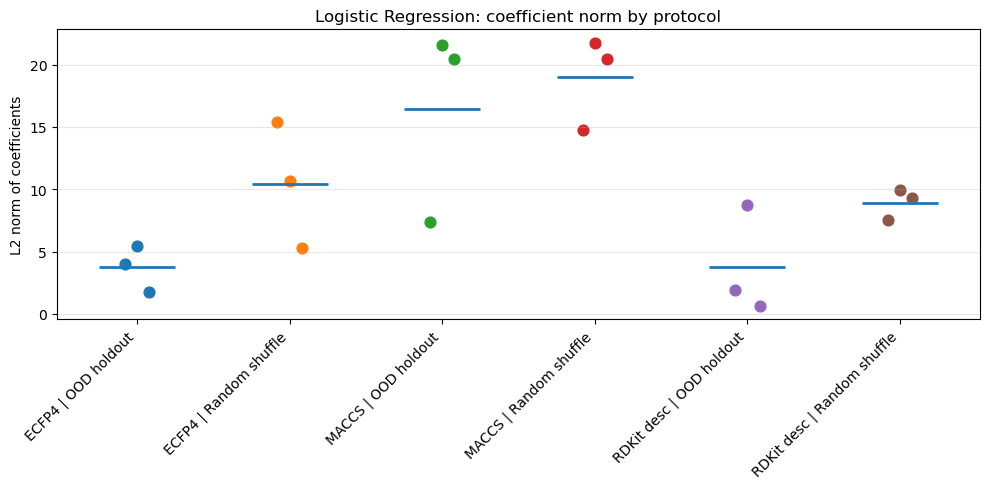

In [6]:
plot_df = lr_table.copy()
plot_df["experiment_label"] = plot_df["fingerprint"] + " | " + plot_df["protocol"]

labels = plot_df["experiment_label"].unique()
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 5))

for i, label in enumerate(labels):
    values = plot_df.loc[plot_df["experiment_label"] == label, "l2_norm"].values
    jitter = np.linspace(-0.08, 0.08, len(values))
    ax.scatter(np.repeat(i, len(values)) + jitter, values, s=60)
    ax.hlines(np.mean(values), i - 0.25, i + 0.25, linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("L2 norm of coefficients")
ax.set_title("Logistic Regression: coefficient norm by protocol")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "04_lr_l2_norm_by_protocol.png", dpi=300, bbox_inches="tight")
plt.show()

# LR non-zero coefficients

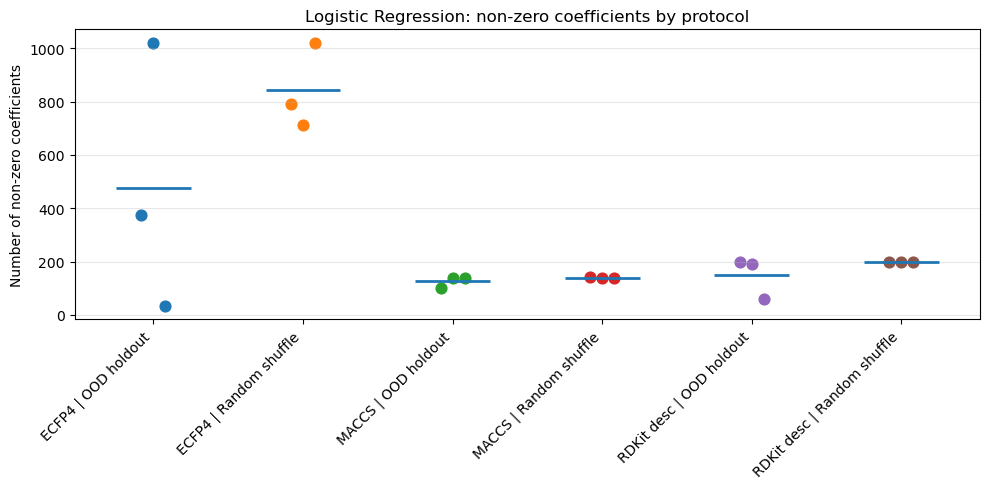

In [7]:
plot_df = lr_table.copy()
plot_df["experiment_label"] = plot_df["fingerprint"] + " | " + plot_df["protocol"]

labels = plot_df["experiment_label"].unique()
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 5))

for i, label in enumerate(labels):
    values = plot_df.loc[plot_df["experiment_label"] == label, "n_nonzero_coefficients"].values
    jitter = np.linspace(-0.08, 0.08, len(values))
    ax.scatter(np.repeat(i, len(values)) + jitter, values, s=60)
    ax.hlines(np.mean(values), i - 0.25, i + 0.25, linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Number of non-zero coefficients")
ax.set_title("Logistic Regression: non-zero coefficients by protocol")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "05_lr_nonzero_coefficients_by_protocol.png", dpi=300, bbox_inches="tight")
plt.show()

# LR L2 norm vs gap

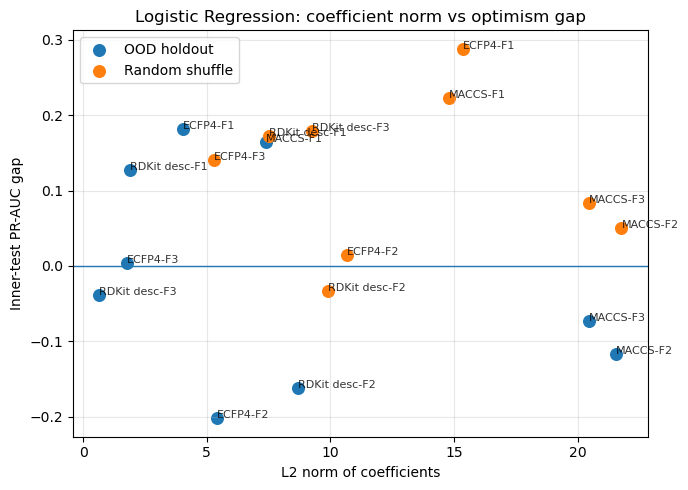

In [8]:
plot_df = lr_table.copy()

fig, ax = plt.subplots(figsize=(7, 5))

for protocol in plot_df["protocol"].unique():
    sub = plot_df[plot_df["protocol"] == protocol]

    ax.scatter(
        sub["l2_norm"],
        sub["inner_test_gap"],
        s=70,
        label=protocol,
    )

for _, row in plot_df.iterrows():
    ax.text(
        row["l2_norm"],
        row["inner_test_gap"],
        f"{row['fingerprint']}-F{int(row['fold'])}",
        fontsize=8,
        alpha=0.8,
    )

ax.axhline(0, linewidth=1)
ax.set_xlabel("L2 norm of coefficients")
ax.set_ylabel("Inner-test PR-AUC gap")
ax.set_title("Logistic Regression: coefficient norm vs optimism gap")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "06_lr_l2_norm_vs_gap.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Linear SVM complexity


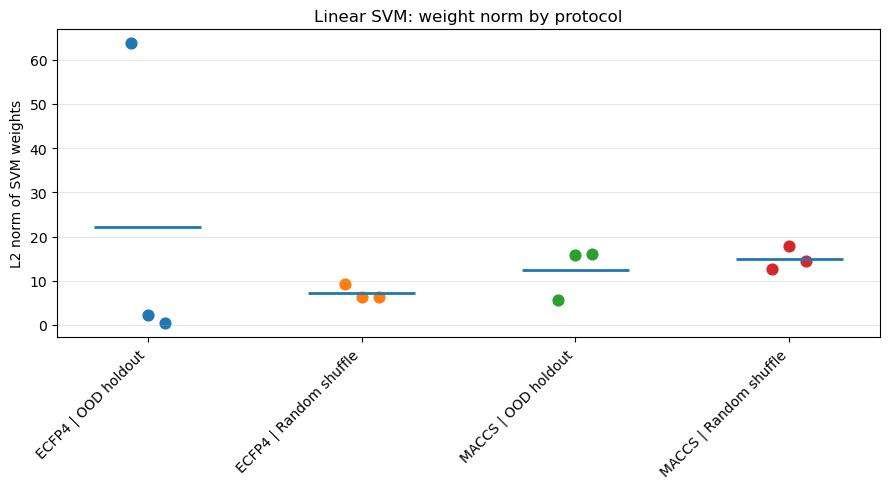

In [9]:
plot_df = svm_table.copy()
plot_df["experiment_label"] = plot_df["fingerprint"] + " | " + plot_df["protocol"]

labels = plot_df["experiment_label"].unique()
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(9, 5))

for i, label in enumerate(labels):
    values = plot_df.loc[plot_df["experiment_label"] == label, "l2_norm"].values
    jitter = np.linspace(-0.08, 0.08, len(values))
    ax.scatter(np.repeat(i, len(values)) + jitter, values, s=60)
    ax.hlines(np.mean(values), i - 0.25, i + 0.25, linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("L2 norm of SVM weights")
ax.set_title("Linear SVM: weight norm by protocol")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "07_svm_l2_norm_by_protocol.png", dpi=300, bbox_inches="tight")
plt.show()

# SVM margin by protocol

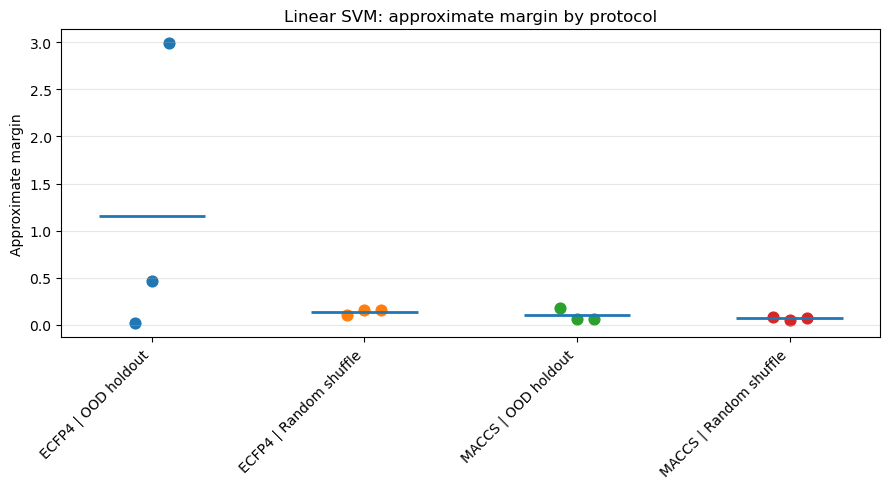

In [10]:
plot_df = svm_table.copy()
plot_df["experiment_label"] = plot_df["fingerprint"] + " | " + plot_df["protocol"]

labels = plot_df["experiment_label"].unique()
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(9, 5))

for i, label in enumerate(labels):
    values = plot_df.loc[plot_df["experiment_label"] == label, "approx_margin"].values
    jitter = np.linspace(-0.08, 0.08, len(values))
    ax.scatter(np.repeat(i, len(values)) + jitter, values, s=60)
    ax.hlines(np.mean(values), i - 0.25, i + 0.25, linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Approximate margin")
ax.set_title("Linear SVM: approximate margin by protocol")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "08_svm_margin_by_protocol.png", dpi=300, bbox_inches="tight")
plt.show()

# SVM margin vs test PR-AUC

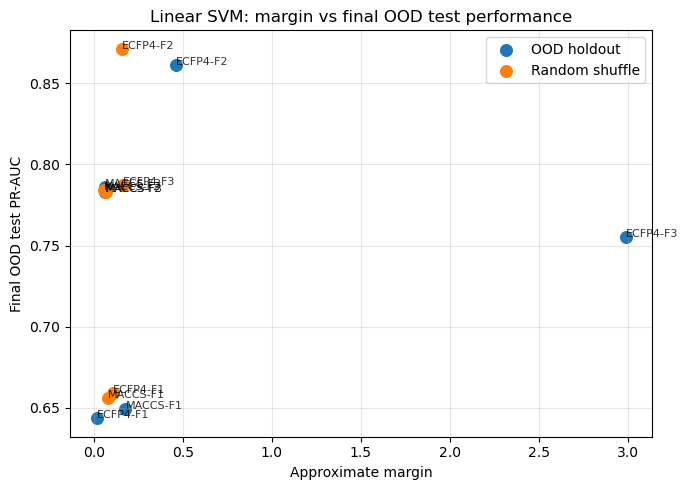

In [11]:
plot_df = svm_table.copy()

fig, ax = plt.subplots(figsize=(7, 5))

for protocol in plot_df["protocol"].unique():
    sub = plot_df[plot_df["protocol"] == protocol]

    ax.scatter(
        sub["approx_margin"],
        sub["test_pr_auc"],
        s=70,
        label=protocol,
    )

for _, row in plot_df.iterrows():
    ax.text(
        row["approx_margin"],
        row["test_pr_auc"],
        f"{row['fingerprint']}-F{int(row['fold'])}",
        fontsize=8,
        alpha=0.8,
    )

ax.set_xlabel("Approximate margin")
ax.set_ylabel("Final OOD test PR-AUC")
ax.set_title("Linear SVM: margin vs final OOD test performance")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "09_svm_margin_vs_test_pr_auc.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Train–validation–test PR-AUC profile

We compared the three performance levels:

- train PR-AUC
- inner validation PR-AUC
- final OOD test PR-AUC

This allows us to visualize both:

- train-to-validation gap
- validation-to-test gap

A strong random shuffle effect should appear as a high inner validation score that does not translate into a similarly high OOD test score.

# Triple PR-AUC profile per model

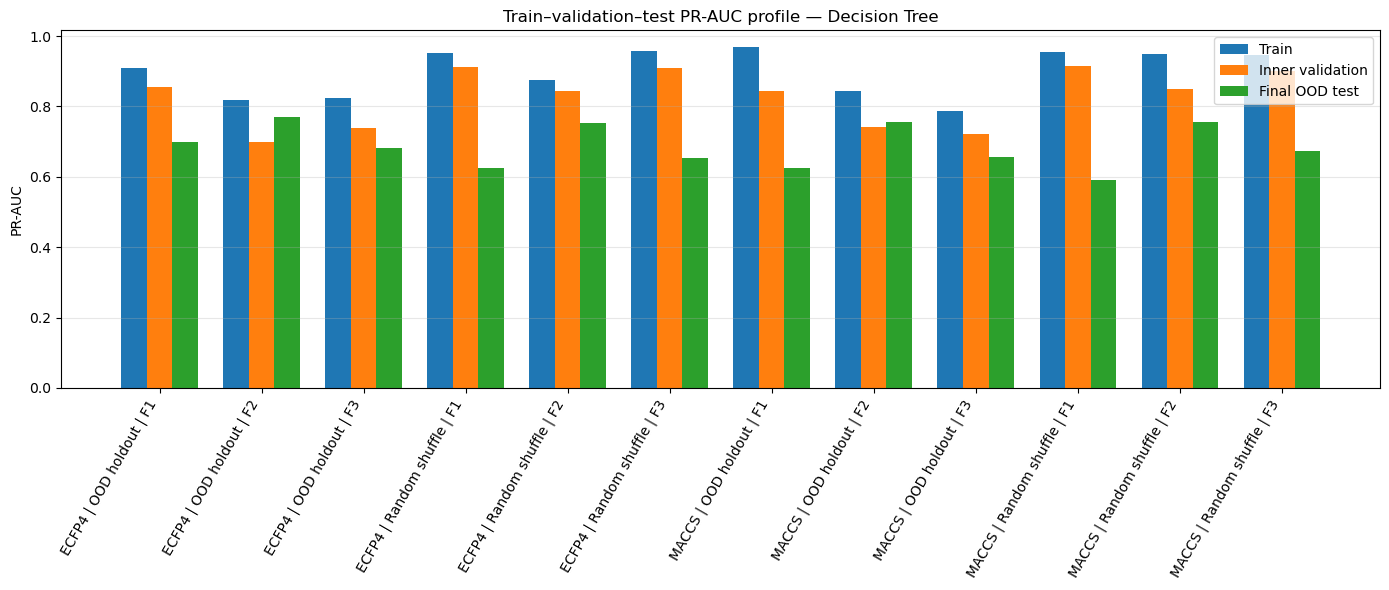

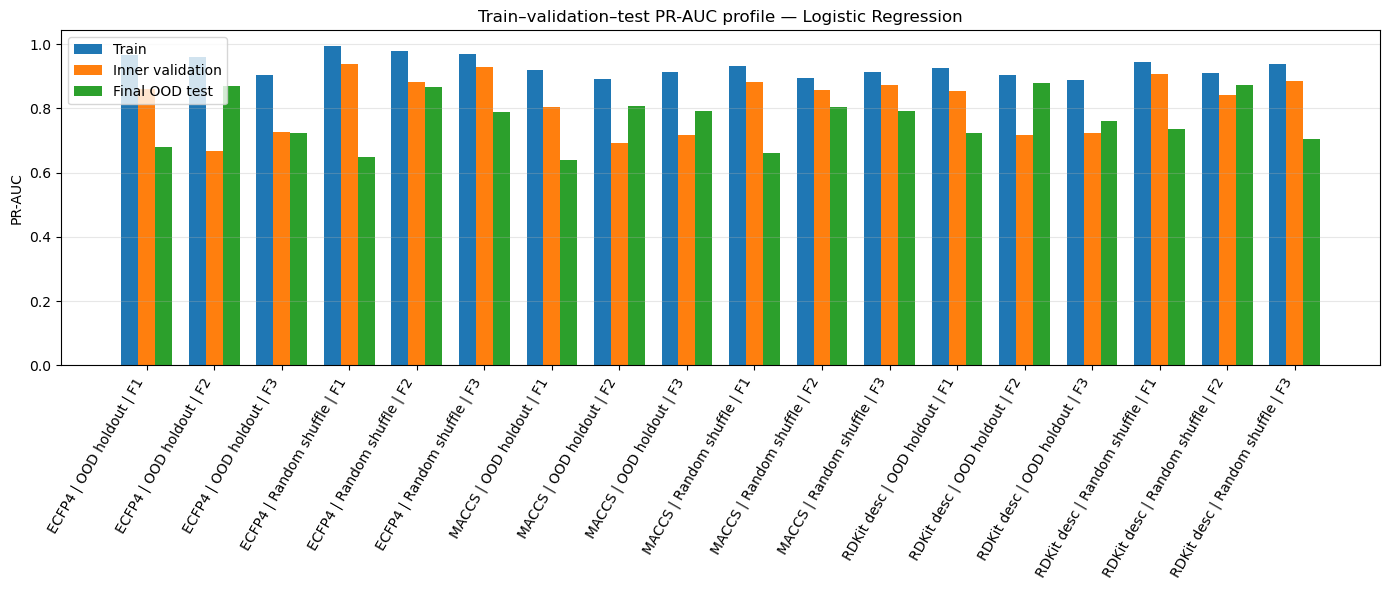

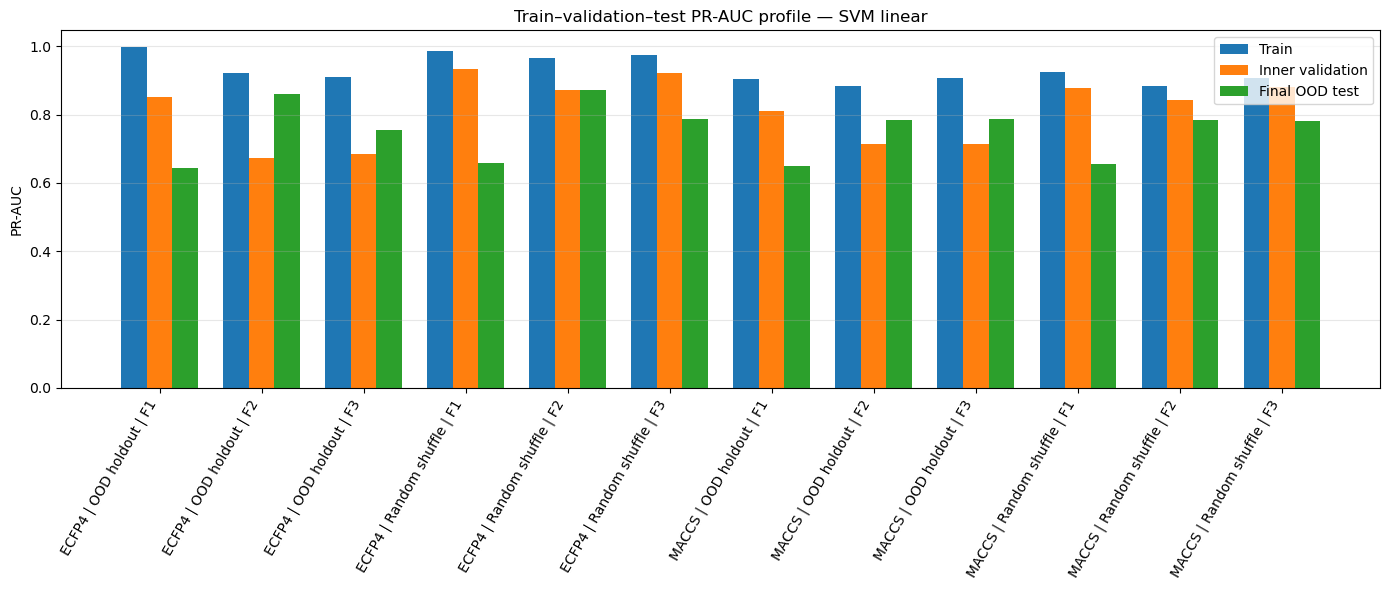

In [12]:
plot_df = gap_analysis.copy()

score_cols = ["train_pr_auc", "inner_pr_auc", "test_pr_auc"]
score_labels = ["Train", "Inner validation", "Final OOD test"]

models = plot_df["model"].unique()

for model in models:
    sub_model = plot_df[plot_df["model"] == model].copy()

    sub_model["experiment_label"] = (
        sub_model["fingerprint"]
        + " | "
        + sub_model["protocol"]
        + " | F"
        + sub_model["fold"].astype(int).astype(str)
    )

    labels = sub_model["experiment_label"].tolist()
    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 6))

    for i, score_col in enumerate(score_cols):
        ax.bar(
            x + (i - 1) * width,
            sub_model[score_col],
            width,
            label=score_labels[i],
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=60, ha="right")
    ax.set_ylabel("PR-AUC")
    ax.set_title(f"Train–validation–test PR-AUC profile — {model}")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()

    safe_model = model.lower().replace(" ", "_")
    plt.savefig(
        FIG_DIR / f"10_triple_profile_{safe_model}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()